In [1]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
#Read in merged data
merged_data = pd.read_csv('/Users/juliaesposito/CSYS_5870/Semester_project/all_merged_df.csv')

In [3]:
merged_data['median_household_income'] = pd.to_numeric(merged_data['median_household_income'], errors = "coerce")

In [4]:
#Make fips as string
merged_data['fips'] = merged_data['fips'].astype(str)

In [5]:
#Calculate various measures of change over time

fi = merged_data[["fips", "year", "food_insecurity_rate"]]

#Overall mean 2010-2022
fi_mean_10_22 = fi.groupby("fips")["food_insecurity_rate"].mean().rename("fi_mean_10_22")

#Recent/Short-term exposure mean 2020-2022
fi_short = fi[fi["year"] >= 2020].groupby("fips")["food_insecurity_rate"].mean().rename("fi_short")

#Medium-term exposure mean
fi_medium = fi[fi["year"].isin([2015, 2016, 2017, 2018, 2019])].groupby("fips")["food_insecurity_rate"].mean().rename("fi_medium")

#Medium-term cumulative exposure
fi_medium_cumulative = fi[fi["year"].isin([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])].groupby("fips")["food_insecurity_rate"].mean().rename("fi_medium_cumulative")

#Long-term exposure mean
fi_long = fi[fi["year"].isin([2010, 2011, 2012, 2013, 2014])].groupby("fips")["food_insecurity_rate"].mean().rename("fi_long")

#Food insecurity volatility - how much is a county's food insecurity rate fluctuating
fi_volatility_10_22 = fi.groupby("fips")["food_insecurity_rate"].std().rename("fi_volatility_10_22")

#Crude change between 2010 and 2022
fi_2010 = fi[fi["year"] == 2010].set_index("fips")["food_insecurity_rate"]
fi_2022 = fi[fi["year"] == 2022].set_index("fips")["food_insecurity_rate"]
fi_change_10_22 = (fi_2022 - fi_2010).rename("fi_change_10_22")


def calc_slope(group):
    years = group["year"].values
    fi_values = group["food_insecurity_rate"].values
    slope = np.polyfit(years, fi_values, 1)[0]
    return slope

fi_trend = fi.groupby("fips").apply(calc_slope).rename("fi_trend")

/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48768/2568948671.py:32: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48768/2568948671.py:32: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48768/2568948671.py:32: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48768/2568948671.py:32: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48768/2568948671.py:32: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, fi_values, 1)[0]
/var/folders/cw/f9qklq2518177kb19y3vjmhr0000gn/T/ipykernel_48768/2568948671.py:32: RankWarning: Polyfit may be poorly conditi

In [6]:
#Merge all the change measures into one dataframe

fi_features = (
    pd.concat([fi_mean_10_22, fi_short, fi_medium, fi_medium_cumulative, fi_long, fi_volatility_10_22, fi_change_10_22, fi_trend], axis=1)
      .reset_index()
)

In [7]:
#Merge change measures with health and census data
census_health_df = merged_data[merged_data["year"] == 2022]

census_health_df = census_health_df[['fips', 'state_name', 'obesity_rate', 'diabetes_rate', 'median_household_income', 'per_families_wo_employment', 'per_col_grad', 'per_hs_grad', 'per_white_only', 'per_over65']].drop_duplicates("fips")

final_df = fi_features.merge(census_health_df, on="fips", how="inner")
final_df

,fips,fi_mean_10_22,fi_short,fi_medium,fi_medium_cumulative,fi_long,fi_volatility_10_22,fi_change_10_22,fi_trend,state_name,obesity_rate,diabetes_rate,median_household_income,per_families_wo_employment,per_col_grad,per_hs_grad,per_white_only,per_over65
0,10001,0.127615,0.124667,0.1282,0.126875,0.1288,0.006199,0.010,-0.000302,de,0.393,0.111,69278.0,0.177,0.263,0.889,0.614,0.176
1,10003,0.113462,0.104667,0.1120,0.109250,0.1202,0.009043,-0.001,-0.001593,de,0.376,0.116,85309.0,0.130,0.383,0.925,0.586,0.162
2,10005,0.107308,0.114333,0.1036,0.107625,0.1068,0.009141,0.021,0.000819,de,0.386,0.099,75406.0,0.262,0.317,0.901,0.780,0.292
3,1001,0.139917,0.143000,0.1405,0.141571,0.1376,0.007856,0.017,0.000933,al,0.384,0.113,68315.0,0.179,0.296,0.904,0.744,0.156
4,1003,0.130538,0.130333,0.1264,0.127875,0.1348,0.008847,0.015,-0.000319,al,0.368,0.102,71039.0,0.203,0.326,0.916,0.840,0.212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3139,9150,0.127000,0.127000,NaN,0.127000,NaN,NaN,NaN,0.000031,ct,0.328,0.084,83119.0,0.154,0.250,0.913,0.852,0.171
3140,9160,0.127000,0.127000,NaN,0.127000,NaN,NaN,NaN,0.000031,ct,0.306,0.082,87971.0,0.144,0.379,0.932,0.823,0.204
3141,9170,0.135000,0.135000,NaN,0.135000,NaN,NaN,NaN,0.000033,ct,0.320,0.096,83617.0,0.130,0.404,0.914,0.675,0.175
3142,9180,0.134000,0.134000,NaN,0.134000,NaN,NaN,NaN,0.000033,ct,0.334,0.091,80330.0,0.162,0.338,0.924,0.789,0.189


In [8]:
#Remove NAs for analyses
final_df = final_df.dropna()

Hierarchical Linear Regressions

Diabetes
1a. Food Insecurity Predictor only

                            OLS Regression Results                            
Dep. Variable:          diabetes_rate   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     3637.
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:19:25   Log-Likelihood:                 8574.5
No. Observations:                3130   AIC:                        -1.715e+04
Df Residuals:                    3128   BIC:                        -1.713e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0468      0.001     42.289

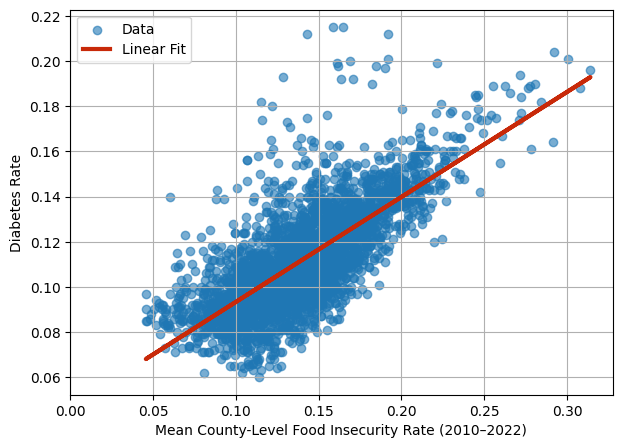

In [9]:
X_original = final_df['fi_mean_10_22']
y = final_df['diabetes_rate']

X = sm.add_constant(X_original)

model=sm.OLS(y, X).fit()

print(model.summary())

y_pred = model.predict(X)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_original, y, alpha=0.6, label='Data')
plt.plot(X_original, y_pred, linewidth=3, label='Linear Fit', color = "#C82909")

plt.xlabel("Mean County-Level Food Insecurity Rate (2010–2022)")
plt.ylabel("Diabetes Rate")
plt.xlim(left=0)
plt.legend()
plt.grid(True)
plt.show()


1b. Food insecurity + socioeconomic measures

In [10]:
X = final_df[['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'per_white_only', 'per_over65']]
y = final_df['diabetes_rate']

X = sm.add_constant(X)

model=sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          diabetes_rate   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     2293.
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:19:25   Log-Likelihood:                 9779.1
No. Observations:                3130   AIC:                        -1.955e+04
Df Residuals:                    3124   BIC:                        -1.951e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Diabetes 1c. Food insecurity + SES factors + State Fixed Effects

In [11]:
model = smf.ols("diabetes_rate ~ fi_mean_10_22 + median_household_income + per_hs_grad + per_white_only + per_over65 + C(state_name)", data=final_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          diabetes_rate   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     680.7
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:19:25   Log-Likelihood:                 11376.
No. Observations:                3130   AIC:                        -2.264e+04
Df Residuals:                    3075   BIC:                        -2.231e+04
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

Obesity
2a. Food insecurity only

                            OLS Regression Results                            
Dep. Variable:           obesity_rate   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     891.2
Date:                Fri, 12 Dec 2025   Prob (F-statistic):          1.58e-172
Time:                        21:19:25   Log-Likelihood:                 5566.0
No. Observations:                3130   AIC:                        -1.113e+04
Df Residuals:                    3128   BIC:                        -1.112e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.2957      0.003    102.203

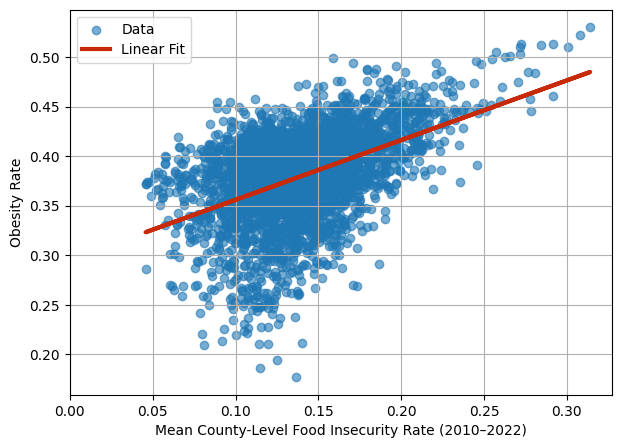

In [12]:
X_original = final_df['fi_mean_10_22']
y = final_df['obesity_rate']

X = sm.add_constant(X_original)

model=sm.OLS(y, X).fit()

print(model.summary())

y_pred = model.predict(X)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_original, y, alpha=0.6, label='Data')
plt.plot(X_original, y_pred, linewidth=3, label='Linear Fit', color = "#C82909")

plt.xlabel("Mean County-Level Food Insecurity Rate (2010–2022)")
plt.ylabel("Obesity Rate")
plt.xlim(left=0)
plt.legend()
plt.grid(True)
plt.show()

2b. Food insecurity and SES factors

In [13]:
X = final_df[['fi_mean_10_22', 'median_household_income', 'per_hs_grad', 'per_white_only', 'per_over65']]
y = final_df['obesity_rate']

X = sm.add_constant(X)

model=sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           obesity_rate   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     479.3
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:19:25   Log-Likelihood:                 6064.7
No. Observations:                3130   AIC:                        -1.212e+04
Df Residuals:                    3124   BIC:                        -1.208e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

2c. Food insecurity + SES + State fixed effects

In [14]:
model = smf.ols("obesity_rate ~ fi_mean_10_22 + median_household_income + per_hs_grad + per_white_only + per_over65 + C(state_name)", data=final_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           obesity_rate   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     170.8
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:19:25   Log-Likelihood:                 7342.7
No. Observations:                3130   AIC:                        -1.458e+04
Df Residuals:                    3075   BIC:                        -1.424e+04
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 